# African Credit Scoring Challenge 


## <a id="1"></a>Introduction

Dans un contexte de croissance rapide des marchés financiers africains, caractérisés par une diversité démographique et des conditions économiques dynamiques, les institutions financières font face à un défi majeur : évaluer avec précision le risque de défaut de crédit. Une mauvaise évaluation de ce risque peut engendrer des pertes financières importantes et freiner l’inclusion financière.

Ce projet s’inscrit dans le cadre du Défi Africain de Credit Scoring, qui consiste à développer un modèle de machine learning robuste et généralisable capable de prédire la probabilité de défaut de paiement d’un client à partir de ses données financières. L’objectif ultime est de fournir une solution de scoring de crédit permettant une meilleure prise de décision, une réduction du risque et une extension plus sûre des services financiers vers de nouveaux clients ou marchés.

## Objectif

L'objectif principal de ce projet est de :

-   Prédire la probabilité qu'un client fasse défaut sur un prêt, à l’aide de ses informations personnelles et financières ;
-   Concevoir un modèle de scoring de crédit basé sur les probabilités de défaut, capable de classifier les clients selon leur niveau de risque ;
-   Créer un pipeline de modélisation complet, incluant l’analyse exploratoire, la préparation des données, l'entraînement, la validation, et le déploiement via une API.

##  Choix du dataset

Le jeu de données utilisé est issu de la plateforme Zindi et représente un cas concret de crédit dans un pays africain. Ce dataset comprend les informations financières, sociodémographiques et comportementales de plusieurs clients (existants ou nouveaux), associées à une étiquette indiquant s’ils ont remboursé leur prêt ou non.

La pertinence de ce dataset repose sur :

-   Sa nature réelle et contextualisée à l’Afrique ;
-   La présence d’un déséquilibre marqué entre les clients solvables et non solvables, représentatif des situations réelles de crédit ;
-   La richesse des variables (quantitatives, qualitatives, temporelles), permettant d’exploiter différentes approches de modélisation.



In [16]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from scipy.stats import mode


from imblearn.over_sampling import BorderlineSMOTE
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier



## <a id="2"></a>Chargement et inspection des données

Dans cette section, nous procédons au chargement des jeux de données d’entraînement et de test, puis à une première inspection afin de mieux comprendre leur structure et leurs caractéristiques générales.

In [17]:
# Chargement du dataset
train = pd.read_csv('data/Train.csv')
test = pd.read_csv('data/Test.csv')

display("Train", train.head(), train.shape, "Test", test.head(), test.shape)

'Train'

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0


(68654, 16)

'Test'

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid
0,ID_269404226088267278,269404,Kenya,226088,267278,Type_1,1919.0,1989.0,2022-07-27,2022-08-03,7,Repeat Loan,575.7,0.300000,597.0
1,ID_255356300042267278,255356,Kenya,300042,267278,Type_1,2138.0,2153.0,2022-11-16,2022-11-23,7,Repeat Loan,0.0,0.000000,0.0
2,ID_257026243764267278,257026,Kenya,243764,267278,Type_1,8254.0,8304.0,2022-08-24,2022-08-31,7,Repeat Loan,207.0,0.025079,208.0
3,ID_264617299409267278,264617,Kenya,299409,267278,Type_1,3379.0,3379.0,2022-11-15,2022-11-22,7,Repeat Loan,1013.7,0.300000,1014.0
4,ID_247613296713267278,247613,Kenya,296713,267278,Type_1,120.0,120.0,2022-11-10,2022-11-17,7,Repeat Loan,36.0,0.300000,36.0


(18594, 15)

## Structure du dataset 

**ID** : Identifiant unique pour chaque entrée du jeu de données.

**customer_id** : Identifiant unique pour chaque client dans le jeu de données.

**country_id** : Identifiant ou code représentant le pays où réside le client ou où le prêt a été accordé.

**tbl_loan_id** : Identifiant unique pour chaque prêt associé au client.

**Total_Amount** : Le montant total du prêt initialement versé au client.

**Total_Amount_to_Repay** : Le montant total que le client doit rembourser, incluant le capital, les intérêts et les frais.

**loan_type** : La catégorie ou le type de prêt.

**disbursement_date** : La date à laquelle le montant du prêt a été versé au client.

**duration** : La durée du prêt, généralement exprimée en jours.

**lender_id** : Identifiant unique pour le prêteur ou l'institution ayant accordé le prêt.

**New_versus_Repeat** : Indique si le prêt est le premier prêt du client ("New") ou s'il a déjà contracté des prêts auparavant ("Repeat").

**Amount_Funded_By_Lender**: La portion du prêt financée directement par le prêteur.

**Lender_portion_Funded**: Pourcentage du montant total du prêt financé par le prêteur.

**due_date** : La date limite à laquelle le remboursement du prêt est dû.

**Lender_portion_to_be_repaid** : La portion du prêt impayé qui doit être remboursée au prêteur.

**target** : Cette variable prend la valeur 0 ou 1. La valeur 1 signifie que le client n'a pas remboursé le prêt (défaut de paiement), tandis que la valeur 0 signifie que le client a remboursé le prêt.

In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68654 entries, 0 to 68653
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           68654 non-null  object 
 1   customer_id                  68654 non-null  int64  
 2   country_id                   68654 non-null  object 
 3   tbl_loan_id                  68654 non-null  int64  
 4   lender_id                    68654 non-null  int64  
 5   loan_type                    68654 non-null  object 
 6   Total_Amount                 68654 non-null  float64
 7   Total_Amount_to_Repay        68654 non-null  float64
 8   disbursement_date            68654 non-null  object 
 9   due_date                     68654 non-null  object 
 10  duration                     68654 non-null  int64  
 11  New_versus_Repeat            68654 non-null  object 
 12  Amount_Funded_By_Lender      68654 non-null  float64
 13  Lender_portion_F

In [19]:
# Valeurs manquantes
print(f"Il y a {train.isna().sum().sum()} valeurs manquantes dans le jeu de données.")

Il y a 0 valeurs manquantes dans le jeu de données.


## <a id="4"></a>Analyse exploratoire des données
Nous allons créer des fonctions d’aide à la visualisation afin de mieux comprendre la distribution de nos données.

In [20]:
def plot_continuous(df, column, transform=None):
    """
        Crée une visualisation pour les variables continues avec des transformations optionnelles.
        
        Paramètres :
        df (DataFrame) : DataFrame d'entrée
        column (str) : Nom de la colonne à visualiser
        transform (str) : Type de transformation ('log' ou 'sqrt')
    """
    fig, axs = plt.subplots(2, 2, figsize=(15, 15))
    
  
    sns.histplot(df[column], kde=True, ax=axs[0, 0])
    axs[0, 0].set_title(f'Distribution of {column}')
    axs[0, 0].set_xlabel(column)

    sns.boxplot(y=df[column], ax=axs[1, 0])
    axs[1, 0].set_title(f'Box Plot of {column}')
    axs[1, 0].set_ylabel(column)

    if transform == 'log':
        transformed_data = np.log1p(df[column])
        transform_label = 'Log'
    elif transform == 'sqrt':
        transformed_data = np.sqrt(df[column])
        transform_label = 'Square Root'
    else:
        transformed_data = None

    if transformed_data is not None:
        sns.histplot(transformed_data, kde=True, ax=axs[0, 1])
        axs[0, 1].set_title(f'{transform_label} Distribution of {column}')
        axs[0, 1].set_xlabel(f'{transform_label}({column})')

        sns.boxplot(y=transformed_data, ax=axs[1, 1])
        axs[1, 1].set_title(f'{transform_label} Box Plot of {column}')
        axs[1, 1].set_ylabel(f'{transform_label}({column})')
    else:
        for ax in [axs[0, 1], axs[1, 1]]:
            ax.remove()

    plt.tight_layout()
    plt.show()

def plot_categorical(df, column):
    """
    Crée une visualisation pour les variables catégorielles.
    
    Paramètres :
    df (DataFrame) : DataFrame d'entrée
    column (str) : Nom de la colonne à visualiser
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    value_counts = df[column].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=ax1)
    ax1.set_title(f'Bar Plot of {column}')
    ax1.set_xlabel(column)
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)

    ax2.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
    ax2.set_title(f'Pie Chart of {column}')

    plt.tight_layout()
    plt.show()

### Analyse des variables catégorielles
Explorons la distribution des variables catégorielles présentes dans notre jeu de données.

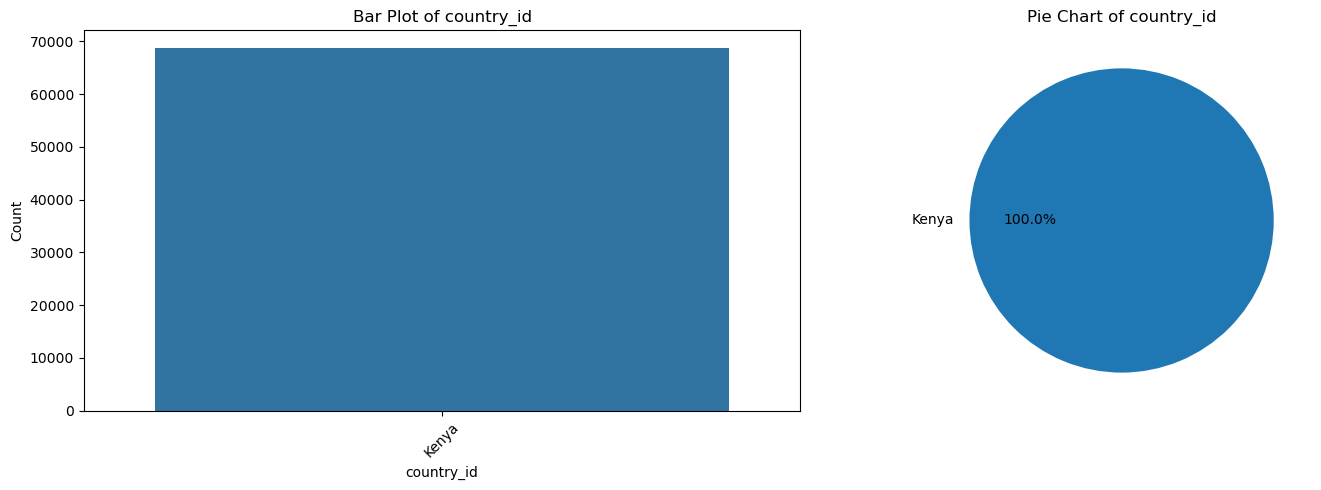

In [21]:
# Analyse de la distribution des pays dans l'ensemble d'entraînement

plot_categorical(train, 'country_id')

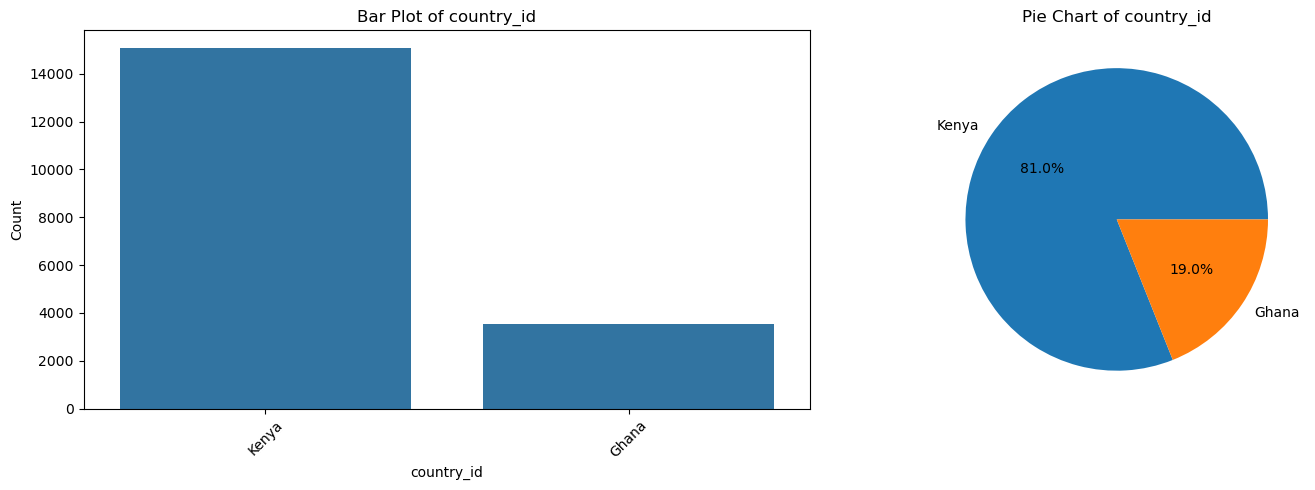

In [22]:
# Analyse de la distribution des pays dans l'ensemble de test

plot_categorical(test, 'country_id')

**Remarque:** Le jeu de test inclut le Ghana, qui n'est pas présent dans les données d'entraînement. Cela signifie que nous devons construire un modèle capable de bien se généraliser à de nouvelles régions.

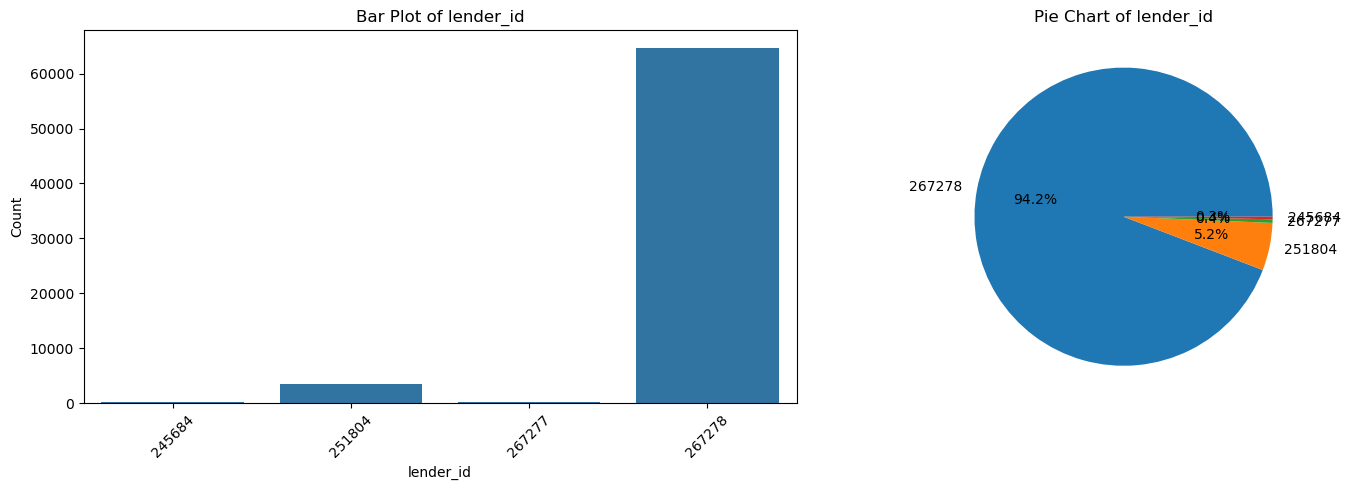

In [23]:
# Analyse de la distribution des prêteurs

plot_categorical(train, 'lender_id')

### Analyse de la variable cible
La variable cible de notre jeu de données représente le risque de défaut de paiement d’un client, généralement encodée sous forme binaire (par exemple: 0 pour aucun défaut, 1 pour défaut de paiement). Examinons la distribution de notre variable cible.

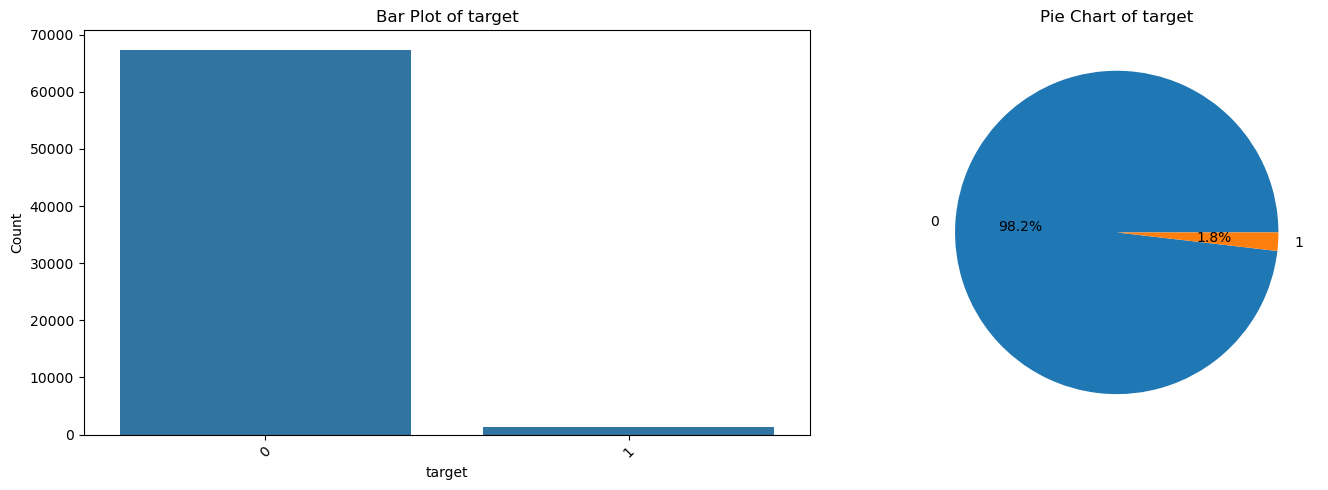

In [24]:
plot_categorical(train, 'target')

### Analyse des variables continues
Examinons la distribution des variables numériques présentes dans notre jeu de données.

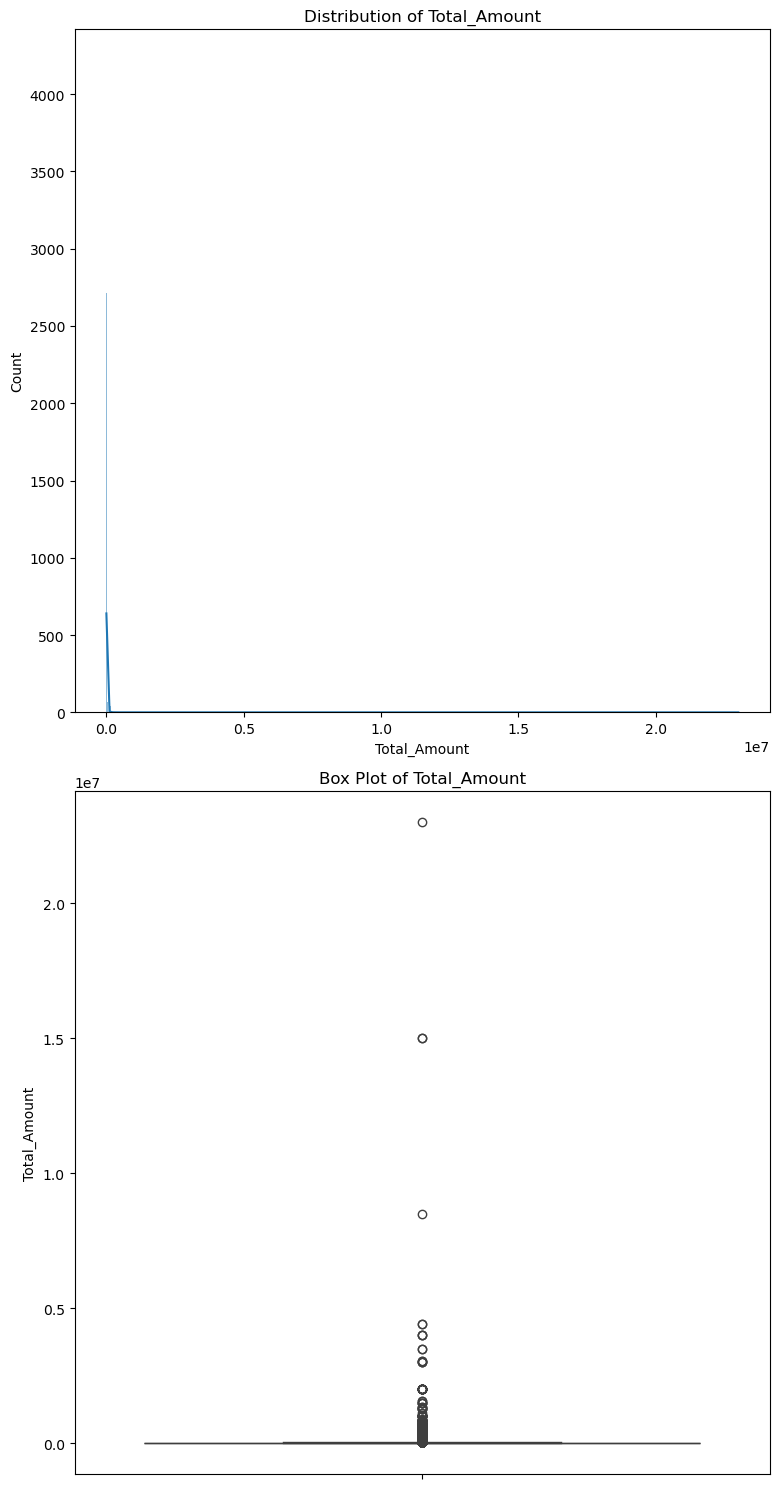

In [25]:
plot_continuous(train, 'Total_Amount')

## <a id="5"></a>Feature Engineering
Nous allons combiner les données d'entraînement et de test pour une ingénierie des caractéristiques cohérente.

In [26]:
# Combinaison des ensembles de données pour un traitement cohérent des caractéristiques
data = pd.concat([train, test]).reset_index(drop=True)

# Conversion des colonnes de dates en datetime
data['disbursement_date'] = pd.to_datetime(data['disbursement_date'], errors='coerce')
data['due_date'] = pd.to_datetime(data['due_date'], errors='coerce')

# Mise à jour du montant total à rembourser par la portion du prêteur à rembourser lorsque le montant total à rembourser est égal à 0
data.loc[data['Total_Amount_to_Repay'] == 0, ['Total_Amount_to_Repay']] += data['Lender_portion_to_be_repaid']

# Calcul des moyennes et médianes des montants à rembourser par client
aggregates = data.groupby('customer_id')['Total_Amount_to_Repay'].agg(['mean', 'median']).reset_index()
aggregates.rename(columns={'mean': 'Mean_Total_Amount', 'median': 'Median_Total_Amount'}, inplace=True)
data = data.merge(aggregates, on='customer_id', how='left')

# Extraction des caractéristiques temporelles à partir des dates
date_cols = ['disbursement_date', 'due_date']
for col in date_cols:
    data[col] = pd.to_datetime(data[col])
    # Extraction du mois, jour, année
    data[col+'_month'] = data[col].dt.month
    data[col+'_day'] = data[col].dt.day
    data[col+'_year'] = data[col].dt.year
    # Calcul de la durée du prêt et des caractéristiques des jours de la semaine
    data[f'loan_term_days'] = (data['due_date'] - data['disbursement_date']).dt.days
    data[f'disbursement_weekday'] = data['disbursement_date'].dt.weekday
    data[f'due_weekday'] = data['due_date'].dt.weekday

# Création de certains ratios financiers et transformations
data['repayment_ratio'] = data['Total_Amount_to_Repay'] / data['Total_Amount']
data['amount_due_per_day'] = (data['Total_Amount_to_Repay'] / data['duration'])
data['log_Total_Amount'] = np.log1p(data['Total_Amount'])
data['log_Total_Amount_to_Repay'] = np.log1p(data['Total_Amount_to_Repay'])
data['log_Amount_Funded_By_Lender'] = np.log1p(data['Amount_Funded_By_Lender'])
data['log_Lender_portion_to_be_repaid'] = np.log1p(data['Lender_portion_to_be_repaid'])
data['amount_to_repay_greater_than_average'] = data['Mean_Total_Amount'] - data['Total_Amount_to_Repay']

# Des valeurs aberrantes ont été observées dans les champs montant total et montant total à rembourser.
# Nous compensons cela en utilisant le 90e percentile
q = 0.9
data['Total_Amount_to_Repay'] = np.where(data['Total_Amount_to_Repay'] >= data['Total_Amount_to_Repay'].quantile(q), data['Total_Amount_to_Repay'].quantile(q), data['Total_Amount_to_Repay'])
data['Total_Amount'] = np.where(data['Total_Amount'] >= data['Total_Amount'].quantile(q), data['Total_Amount'].quantile(q), data['Total_Amount'])

# Traitement des variables catégorielles
cat_cols = data.select_dtypes(include='object').columns

# Encodage des variables catégorielles
le = LabelEncoder()
for col in [col for col in cat_cols if col not in ['loan_type', 'ID']]:
    data[col] = le.fit_transform(data[col])

# Séparation en train et test
train_df = (data[data['ID'].isin(train['ID'].unique())]).fillna(0)
test_df = (data[data['ID'].isin(test['ID'].unique())]).fillna(0)

# Définition des caractéristiques pour la modélisation
features_for_modelling = [col for col in train_df.columns if col not in date_cols + ['ID', 'target', 'country_id', 'loan_type']]

print(f"La forme de train_df est : {train_df.shape}")
print(f"La forme de test_df est : {test_df.shape}")
print(f"La forme de train est : {train.shape}")
print(f"La forme de test est : {test.shape}")
print(f"Les caractéristiques pour la modélisation sont :\n{features_for_modelling}")


La forme de train_df est : (68654, 34)
La forme de test_df est : (18594, 34)
La forme de train est : (68654, 16)
La forme de test est : (18594, 15)
Les caractéristiques pour la modélisation sont :
['customer_id', 'tbl_loan_id', 'lender_id', 'Total_Amount', 'Total_Amount_to_Repay', 'duration', 'New_versus_Repeat', 'Amount_Funded_By_Lender', 'Lender_portion_Funded', 'Lender_portion_to_be_repaid', 'Mean_Total_Amount', 'Median_Total_Amount', 'disbursement_date_month', 'disbursement_date_day', 'disbursement_date_year', 'loan_term_days', 'disbursement_weekday', 'due_weekday', 'due_date_month', 'due_date_day', 'due_date_year', 'repayment_ratio', 'amount_due_per_day', 'log_Total_Amount', 'log_Total_Amount_to_Repay', 'log_Amount_Funded_By_Lender', 'log_Lender_portion_to_be_repaid', 'amount_to_repay_greater_than_average']


## <a id="6"></a>Mise en place du modèle
### Cross Validation

Nous utiliserons une division stratifiée en raison du déséquilibre des classes.

In [27]:

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

### Entraînement et optimisation du modèle

Dans cette étape, nous avons cherché à entraîner et optimiser trois modèles de machine learning : XGBoost, LightGBM et CatBoost. L'objectif est d'ajuster leurs hyperparamètres afin d'atteindre la meilleure performance possible sur le problème donné.

Pour chaque modèle, nous avons utilisé une recherche des hyperparamètres, afin de sélectionner les valeurs optimales qui maximisent la performance du modèle tout en évitant le sur-apprentissage. 

In [28]:
from sklearn.model_selection import GridSearchCV, train_test_split


# Paramètres de la graine aléatoire
seed = 42

# Données
X, y = train_df[features_for_modelling], train_df['target']

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:



# XGBoost 
xgb_model = xgb.XGBRegressor(random_state=seed)
xgb_param_grid = {
    'n_estimators': [100,200,250],
    'max_depth': [5,6,7],
    'learning_rate': [0.1, 0.09, 0.01],
    'subsample': [0.91, 0.92, 0.93],
    'colsample_bytree': [0.68, 0.69, 0.7],
    'gamma': [0.01, 0.005, 0.015],
    'min_child_weight': [1]
}

xgb_grid_search = GridSearchCV(estimator=xgb_model, param_grid=xgb_param_grid, cv=cv, verbose=1, n_jobs=-1)
xgb_grid_search.fit(X_train, y_train)

# LightGBM 
lgb_model = LGBMClassifier(random_state=seed)
lgb_param_grid = {
    'n_estimators': [100,200,250],
    'max_depth': [6,7,8],
    'learning_rate': [0.1, 0.075, 0.07,0.05],
    'num_leaves': [70, 75, 80],
    'feature_fraction': [0.66, 0.65, 0.67],
    'bagging_fraction': [0.66, 0.65, 0.67],
    'lambda_l1': [0.05, 0.06, 0.07],
    'lambda_l2': [0.85, 0.86, 0.87]
}



lgb_grid_search = GridSearchCV(estimator=lgb_model, param_grid=lgb_param_grid, cv=cv, verbose=1, n_jobs=-1)
lgb_grid_search.fit(X_train, y_train)

# CatBoost - Modèle et grille de recherche
cat_model = CatBoostClassifier(silent=True, random_state=seed)
cat_param_grid = {
    'iterations': [500],
    'depth': [6,7,8],
    'learning_rate': [0.1, 0.09, 0.01]
}

cat_grid_search = GridSearchCV(estimator=cat_model, param_grid=cat_param_grid, cv=cv, verbose=1, n_jobs=-1)
cat_grid_search.fit(X_train, y_train)

# Affichage des meilleurs résultats
print("Meilleurs paramètres pour XGBoost : ", xgb_grid_search.best_params_)
print("Meilleurs paramètres pour LightGBM : ", lgb_grid_search.best_params_)
print("Meilleurs paramètres pour CatBoost : ", cat_grid_search.best_params_)


In [29]:
xgb_best_params= {'n_estimators': 250, 'max_depth': 7, 'learning_rate': 0.1, 'subsample': 0.91, 'colsample_bytree': 0.68, 'gamma': 0.01, 'min_child_weight': 1}
lgb_best_params=  {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.07, 'num_leaves': 70, 'feature_fraction': 0.66, 'bagging_fraction': 0.66, 'lambda_l1': 0.06, 'lambda_l2': 0.87}
cat_best_params= {'iterations': 500, 'depth': 7, 'learning_rate': 0.1}


In [30]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

# Validation croisée pour évaluer la performance du modèle

cv_reports = []
f1_scores = []
predictions = []
pred_prob = []
base_estimator = DecisionTreeClassifier()

# Boucle sur chaque pli (fold) de la validation croisée
for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), 1):
    
    # Sélection des données d'entraînement et de validation pour chaque pli
    X_fold_train = X.iloc[train_idx]
    X_fold_valid = X.iloc[valid_idx]
    y_fold_train = y.iloc[train_idx]
    y_fold_valid = y.iloc[valid_idx]
    
    # Application de SMOTE pour générer des échantillons synthétiques
    smote = BorderlineSMOTE(sampling_strategy=0.45, random_state=seed)
    
    # Appliquer SMOTE uniquement sur les données d'entraînement de ce pli
    X_fold_train_smote, y_fold_train_smote = smote.fit_resample(X_fold_train, y_fold_train)
    
    # Calcul de scale_pos_weight pour compenser le déséquilibre des classes
    scale_pos_weight = len(y_fold_train_smote[y_fold_train_smote == 1]) * 0.75 / len(y_fold_train_smote[y_fold_train_smote == 0]) 
    
    # Initialisation des modèles avec les paramètres optimaux
    model1 = xgb.XGBClassifier(**xgb_best_params, scale_pos_weight=scale_pos_weight, random_state=seed)
    model2 = LGBMClassifier(**lgb_best_params, scale_pos_weight=scale_pos_weight, random_state=seed)
    model3 = CatBoostClassifier(**cat_best_params, scale_pos_weight=scale_pos_weight, random_state=seed)

    # Entraînement des modèles sur le pli avec SMOTE
    model1.fit(X_fold_train_smote, y_fold_train_smote)
    model2.fit(X_fold_train_smote, y_fold_train_smote)
    model3.fit(X_fold_train_smote, y_fold_train_smote)

    # Prédiction sur l'ensemble de validation
    pred_1 = model1.predict(X_fold_valid)
    pred_2 = model2.predict(X_fold_valid)
    pred_3 = model3.predict(X_fold_valid)

    # Combinaison des prédictions via la méthode de mode (majorité des votes)
    predictions = mode([pred_1, pred_2, pred_3], axis=0).mode.flatten()

    # Rapport de classification pour ce pli
    report = classification_report(y_fold_valid, predictions, output_dict=True)
    cv_reports.append(report)
        
    # Calcul et stockage du score F1 pour ce pli
    f1 = f1_score(predictions, y_fold_valid)
    f1_scores.append(f1)

    print(f"Pli {fold} - Rapport de classification :")
    print(classification_report(y_fold_valid, predictions))
    print(f"Pli {fold} - Score F1 : {f1:.4f}")
    print("-" * 50)




  File "c:\Users\AMED BAH\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\AMED BAH\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\AMED BAH\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\AMED BAH\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


[LightGBM] [Warning] feature_fraction is set=0.66, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.66
[LightGBM] [Warning] lambda_l1 is set=0.06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.06
[LightGBM] [Warning] lambda_l2 is set=0.87, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.87
[LightGBM] [Warning] bagging_fraction is set=0.66, subsample=1.0 will be ignored. Current value: bagging_fraction=0.66
[LightGBM] [Warning] feature_fraction is set=0.66, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.66
[LightGBM] [Warning] lambda_l1 is set=0.06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.06
[LightGBM] [Warning] lambda_l2 is set=0.87, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.87
[LightGBM] [Warning] bagging_fraction is set=0.66, subsample=1.0 will be ignored. Current value: bagging_fraction=0.66
[LightGBM] [Info] Number of positive: 22746, number of negative: 50547
[LightGBM] [Info]

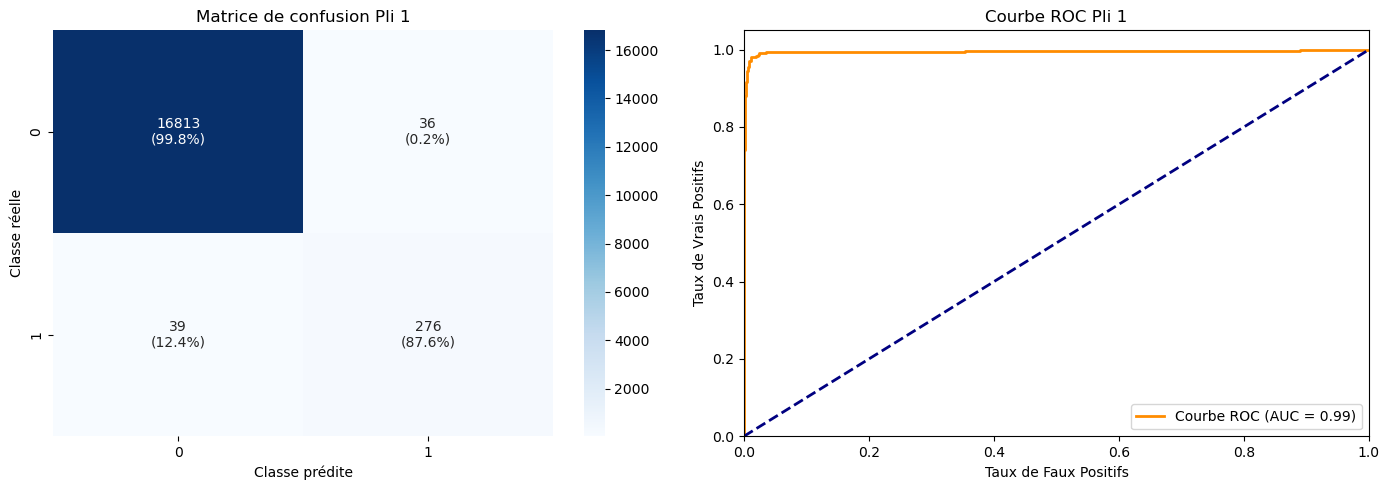

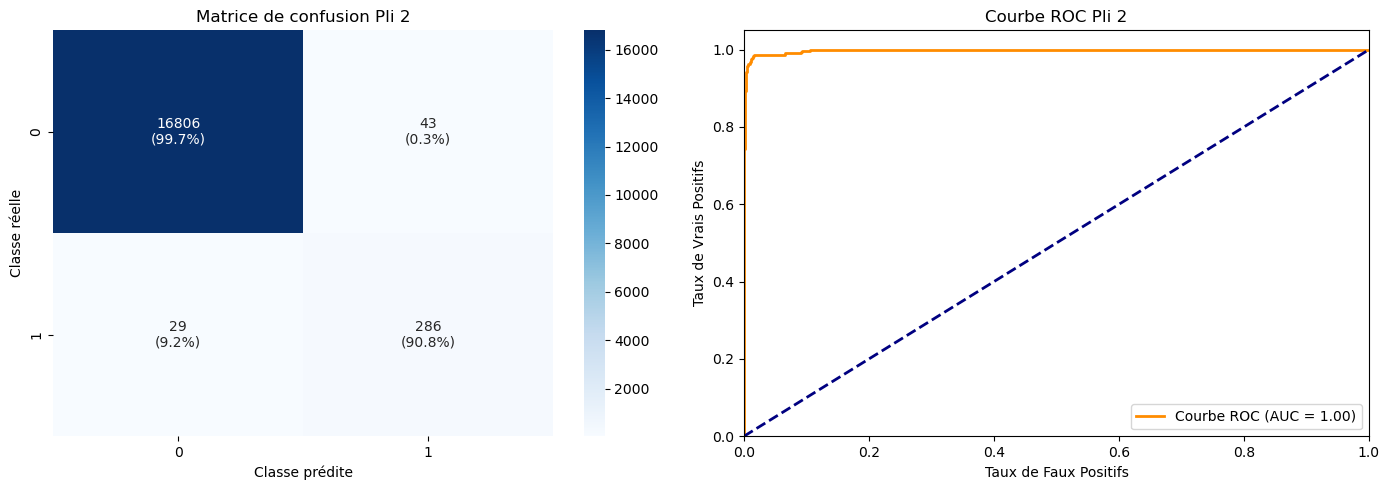

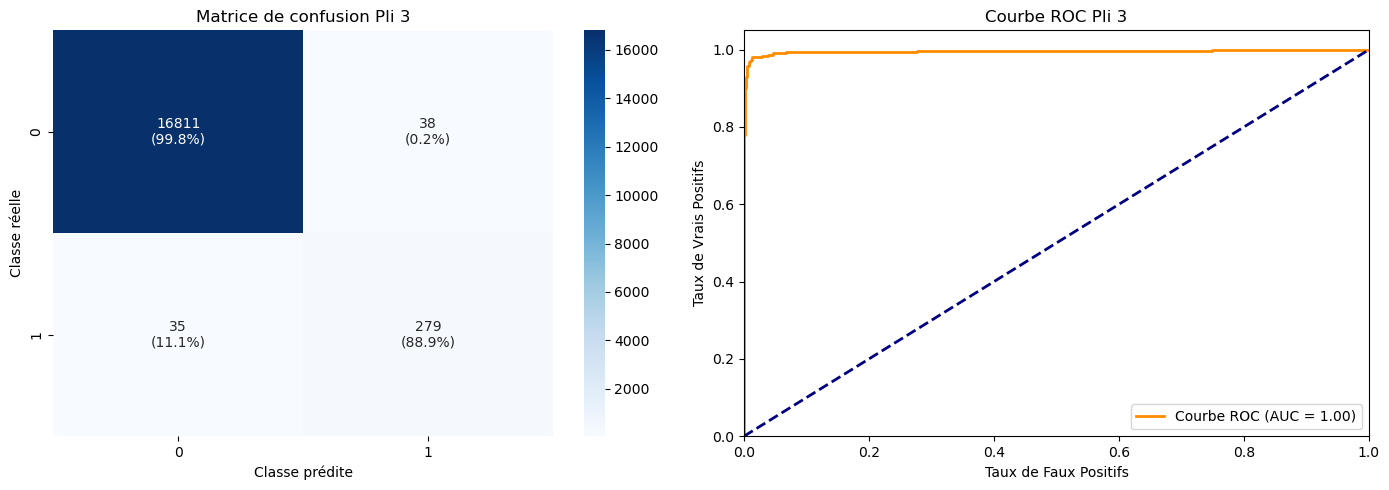

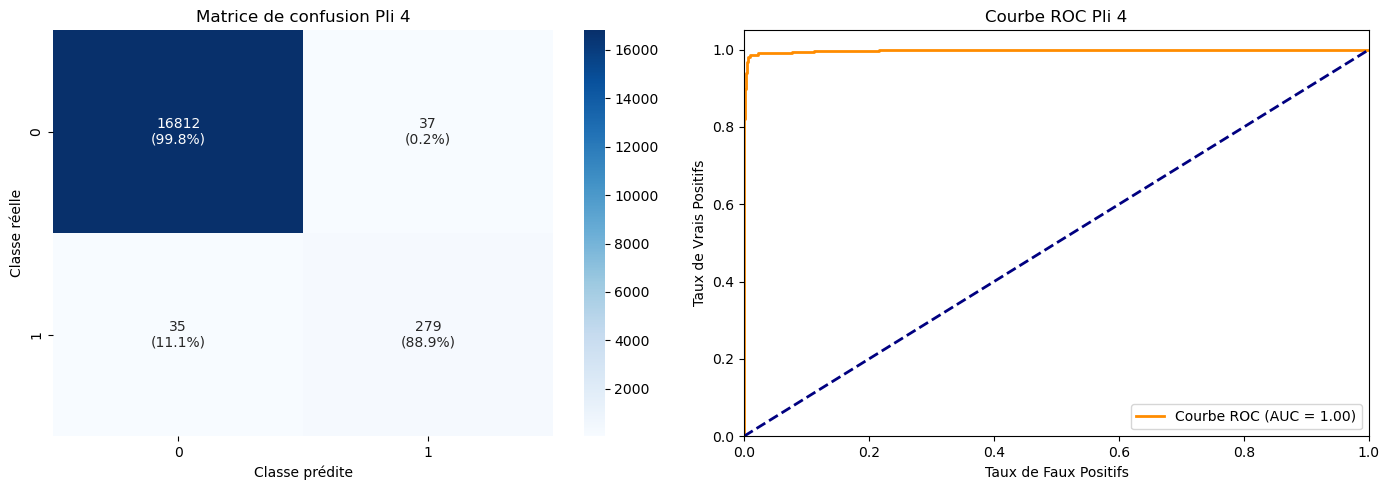

In [50]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, f1_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import BorderlineSMOTE
from scipy.stats import mode
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

# Validation croisée pour évaluer la performance du modèle

cv_reports = []
f1_scores = []
roc_auc_scores = []
predictions = []
pred_prob = []
base_estimator = DecisionTreeClassifier()

# Boucle sur chaque pli (fold) de la validation croisée
for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), 1):
    
    # Sélection des données d'entraînement et de validation pour chaque pli
    X_fold_train = X.iloc[train_idx]
    X_fold_valid = X.iloc[valid_idx]
    y_fold_train = y.iloc[train_idx]
    y_fold_valid = y.iloc[valid_idx]
    
    # Application de SMOTE pour générer des échantillons synthétiques
    smote = BorderlineSMOTE(sampling_strategy=0.45, random_state=seed)
    
    # Appliquer SMOTE uniquement sur les données d'entraînement de ce pli
    X_fold_train_smote, y_fold_train_smote = smote.fit_resample(X_fold_train, y_fold_train)
    
    # Calcul de scale_pos_weight pour compenser le déséquilibre des classes
    scale_pos_weight = len(y_fold_train_smote[y_fold_train_smote == 1]) * 0.75 / len(y_fold_train_smote[y_fold_train_smote == 0]) 
    
    # Initialisation des modèles avec les paramètres optimaux et suppression des warnings
    model1 = xgb.XGBClassifier(**xgb_best_params, scale_pos_weight=scale_pos_weight, random_state=seed, verbosity=0)
    model2 = LGBMClassifier(**lgb_best_params, scale_pos_weight=scale_pos_weight, random_state=seed, verbosity=-1)
    model3 = CatBoostClassifier(**cat_best_params, scale_pos_weight=scale_pos_weight, random_state=seed, silent=True)

    # Entraînement des modèles sur le pli avec SMOTE
    model1.fit(X_fold_train_smote, y_fold_train_smote)
    model2.fit(X_fold_train_smote, y_fold_train_smote)
    model3.fit(X_fold_train_smote, y_fold_train_smote)

    # Prédiction sur l'ensemble de validation
    pred_1 = model1.predict(X_fold_valid)
    pred_2 = model2.predict(X_fold_valid)
    pred_3 = model3.predict(X_fold_valid)

    # Combinaison des prédictions via la méthode de mode (majorité des votes)
    predictions = mode([pred_1, pred_2, pred_3], axis=0).mode.flatten()

    # Rapport de classification pour ce pli
    report = classification_report(y_fold_valid, predictions, output_dict=True)
    cv_reports.append(report)
        
    # Calcul et stockage du score F1 pour ce pli
    f1 = f1_score(predictions, y_fold_valid)
    f1_scores.append(f1)

    # Calcul de la matrice de confusion
    cm = confusion_matrix(y_fold_valid, predictions)
    
    # Calcul des pourcentages par classe réelle (normalisation par ligne)
    cm_sum = cm.sum(axis=1, keepdims=True)
    cm_perc = (cm / cm_sum.astype(float)) * 100

    # Création d'une matrice d'annotations combinant compte et pourcentage
    labels = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            labels[i, j] = f"{cm[i,j]}\n({cm_perc[i,j]:.1f}%)"

    # Création de la figure pour afficher les graphiques sur la même ligne
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 ligne et 2 colonnes pour les graphiques

    # Affichage de la matrice de confusion
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", ax=axes[0])
    axes[0].set_xlabel("Classe prédite")
    axes[0].set_ylabel("Classe réelle")
    axes[0].set_title(f"Matrice de confusion Pli {fold}")

    # Courbe ROC
    fpr, tpr, thresholds = roc_curve(y_fold_valid, model2.predict_proba(X_fold_valid)[:, 1])
    roc_auc = auc(fpr, tpr)
    roc_auc_scores.append(roc_auc)

    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Taux de Faux Positifs')
    axes[1].set_ylabel('Taux de Vrais Positifs')
    axes[1].set_title(f'Courbe ROC Pli {fold}')
    axes[1].legend(loc='lower right')

    # Sauvegarder les graphiques
    plt.tight_layout()
    plt.savefig(f"Fold_{fold}_Confusion_ROC.svg", format="svg")
    plt.show()


In [51]:
# Résumé des résultats de la validation croisée
print(f"Score F1 moyen sur tous les plis : {np.mean(f1_scores):.4f}")

Score F1 moyen sur tous les plis : 0.8847


### Prédiction sur les données de test à l'aide des modèles


In [31]:
X, y = train_df[features_for_modelling], train_df['target']

predictions = []
pred_prob = []
base_estimator = DecisionTreeClassifier()

# Boucle sur chaque pli (fold) de la validation croisée
for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), 1):
    
    # Sélection des données d'entraînement et de validation pour chaque pli
    X_fold_train = X.iloc[train_idx]
    X_fold_valid = X.iloc[valid_idx]
    y_fold_train = y.iloc[train_idx]
    y_fold_valid = y.iloc[valid_idx]
    
    # Application de SMOTE pour générer des échantillons synthétiques
    smote = BorderlineSMOTE(sampling_strategy=0.45, random_state=seed)
    
    # Appliquer SMOTE uniquement sur les données d'entraînement de ce pli
    X_fold_train_smote, y_fold_train_smote = smote.fit_resample(X_fold_train, y_fold_train)
    
    # Calcul de scale_pos_weight pour compenser le déséquilibre des classes
    scale_pos_weight = len(y_fold_train_smote[y_fold_train_smote == 1]) * 0.75 / len(y_fold_train_smote[y_fold_train_smote == 0]) 
    
    # Initialisation des modèles avec les paramètres optimaux
    model1 = xgb.XGBClassifier(**xgb_best_params, scale_pos_weight=scale_pos_weight, random_state=seed)
    model2 = LGBMClassifier(**lgb_best_params, scale_pos_weight=scale_pos_weight, random_state=seed)
    model3 = CatBoostClassifier(**cat_best_params, scale_pos_weight=scale_pos_weight, random_state=seed)
    
    # Entraînement des modèles sur le pli avec SMOTE
    model1.fit(X_fold_train_smote, y_fold_train_smote)
    model2.fit(X_fold_train_smote, y_fold_train_smote)
    model3.fit(X_fold_train_smote, y_fold_train_smote)

    # Prédiction sur l'ensemble de test avec les modèles
    pred_1 = model1.predict(test_df[features_for_modelling])
    pred_2 = model2.predict(test_df[features_for_modelling])
    pred_3 = model3.predict(test_df[features_for_modelling])
    pred_p_1 = model1.predict_proba(test_df[features_for_modelling])
    pred_p_2 = model2.predict_proba(test_df[features_for_modelling])
    pred_p_3 = model3.predict_proba(test_df[features_for_modelling])

    # Ajouter les prédictions
    predictions.append(pred_1)
    predictions.append(pred_2)
    predictions.append(pred_3)
    pred_prob.append(pred_p_1)
    pred_prob.append(pred_p_2)
    pred_prob.append(pred_p_3)


[LightGBM] [Warning] feature_fraction is set=0.66, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.66
[LightGBM] [Warning] lambda_l1 is set=0.06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.06
[LightGBM] [Warning] lambda_l2 is set=0.87, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.87
[LightGBM] [Warning] bagging_fraction is set=0.66, subsample=1.0 will be ignored. Current value: bagging_fraction=0.66
[LightGBM] [Warning] feature_fraction is set=0.66, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.66
[LightGBM] [Warning] lambda_l1 is set=0.06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.06
[LightGBM] [Warning] lambda_l2 is set=0.87, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.87
[LightGBM] [Warning] bagging_fraction is set=0.66, subsample=1.0 will be ignored. Current value: bagging_fraction=0.66
[LightGBM] [Info] Number of positive: 22746, number of negative: 50547
[LightGBM] [Info]

In [32]:

final_predictions = mode(predictions, axis=0).mode.flatten()
final_pred_proba=np.mean(pred_prob,axis=0)
test_df['target'] = final_predictions
test_df[['proba','proba2']]= final_pred_proba

In [33]:
test_df.target.sum()

655.0

### Post-traitement des prédictions pour améliorer le score


In [34]:
# Concaténation et trie les données d'entraînement et de test pour faciliter le post-traitemen
train_test=pd.concat([train_df,test_df])
train_test=(train_test.sort_values(['customer_id','tbl_loan_id','disbursement_date','duration'])).reset_index(drop=True)

In [35]:
def check_loanid_in_train_data(tbl_loan_id):
    '''
    Mise à jour de la cible en fonction de la valeur disponible dans les données d'entraînement.
    Cette vérification permet de s'assurer qu'un prêt n'a qu'une seule décision (0 ou 1), 
    et la cible dans les données d'entraînement prévaut sur celle des données de test.
    '''
    # Vérification si tbl_loan_id existe dans le DataFrame d'entraînement
    if tbl_loan_id in train_df['tbl_loan_id'].values:
        df = train_df[train_df['tbl_loan_id'] == tbl_loan_id]
        target = df.target.values[0]
    else:
        target = 3  # Retourne 3 s'il n'y a pas de correspondance
    return target

def type_3_correction(df):
    '''
    Correction de la mauvaise performance du modèle pour le type de prêt 3 dans les données du Ghana.
    La distribution de ce type de prêt diffère de celle des données d'entraînement.
    Une hypothèse est faite selon laquelle les prêts sont octroyés au client jusqu'à ce qu'il échoue à rembourser.
    Cette fonction applique cette hypothèse pour corriger les prédictions.
    '''
    df1 = df[df['loan_type'] == 'Type_3']
    customer_id = df1.customer_id.unique()
    for customer in customer_id:
        loan_id = df[df['customer_id'] == customer].tail(1).tbl_loan_id.values[0]
        df.loc[df['tbl_loan_id'] == loan_id, 'target'] = 1   
    return df

def correct_loan_ids_with_conflicting_target(df):
    '''
    Mise à jour des prêts afin de garantir qu'ils aient un seul groupe cible (0 ou 1, pas les deux),
    même en cas de présence de plusieurs prêteurs.
    '''
    # Vérification des loan_ids avec des valeurs de cibles différentes
    loan_ids_with_diff_targets = df.groupby('tbl_loan_id')['target'].transform('nunique') > 1

    # Mise à jour des valeurs de la cible à 1 pour ces loan_ids
    df.loc[loan_ids_with_diff_targets, 'target'] = 0
    return df


In [36]:
for i in range(len(train_test)):
    if pd.notna(train_test.loc[i, 'proba']):
        customer_id=train_test.loc[i, 'customer_id']
            
        tbl_loan_id = train_test.loc[i, 'tbl_loan_id']
        target=check_loanid_in_train_data(tbl_loan_id)
            
        if target <2:
            train_test.loc[i, 'target']=target

train_test_f=type_3_correction (train_test)
correct_loan_ids_with_conflicting_target(train_test_f)
test_df=train_test_f[train_test_f['proba'].notna()]

### Sauvegarde des modèles

In [55]:
import joblib

joblib.dump(model1, 'Model/model1.pkl')
joblib.dump(model2, 'Model/model2.pkl')
joblib.dump(model3, 'Model/model3.pkl')


['Model/model3.pkl']

## <a id="1"></a> Score de Crédit
Pour construire la fonction de score de crédit, les éléments suivants ont été pris en compte :

-   Probabilité de défaut : C'est l'une des sorties des modèles. Plus la probabilité est élevée, plus le risque de défaut est grand.
-   Longueur de l'historique de prêt : Il s'agit du nombre de prêts historiques accordés au client. Plus ce nombre est élevé, plus le score de crédit est élevé.
-   Nombre de défauts : Il s'agit du nombre de fois où le client a fait défaut. Plus ce nombre est élevé, plus le score de crédit est bas.
-   Le score de crédit est limité entre 300 et 850 pour respecter les normes généralement utilisées.
 

In [38]:

credit_score_calc = train_test_f.groupby('customer_id').agg(
    distinct_loans=('tbl_loan_id', 'nunique'),
    count_default=('target', 'sum')
).reset_index()


In [39]:
credit_score_calc.head() 

,customer_id,distinct_loans,count_default
0,145,1,0.0
1,161,1,0.0
2,166,1,0.0
3,1487,1,0.0
4,4534,2,0.0


In [40]:

train_test_f=train_test_f.merge(credit_score_calc, on=['customer_id'])
train_test_f.head()

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,...,amount_due_per_day,log_Total_Amount,log_Total_Amount_to_Repay,log_Amount_Funded_By_Lender,log_Lender_portion_to_be_repaid,amount_to_repay_greater_than_average,proba,proba2,distinct_loans,count_default
0,ID_145124016245684,145,1,124016,245684,Type_11,14500.0,15738.0,2022-03-09,2022-04-08,...,524.600000,9.581973,9.663897,9.210440,9.292381,0.0,NaN,NaN,1,0.0
1,ID_161361065267277,161,1,361065,267277,Type_9,11025.0,11686.5,2024-01-15,2024-02-14,...,389.550000,9.308011,9.366275,8.318254,8.376551,0.0,NaN,NaN,1,0.0
2,ID_166124634245684,166,1,124634,245684,Type_11,5881.0,6914.0,2022-03-11,2022-04-10,...,230.466667,8.679652,8.841448,8.679652,8.841448,0.0,NaN,NaN,1,0.0
3,ID_1487125800245684,1487,1,125800,245684,Type_11,7000.0,7850.0,2022-03-14,2022-04-13,...,261.666667,8.853808,8.968396,8.853808,8.968396,0.0,NaN,NaN,1,0.0
4,ID_4534122904245684,4534,1,122904,245684,Type_11,9565.0,10672.0,2022-03-07,2022-04-06,...,355.733333,9.165970,9.275472,9.165970,9.275472,16366.5,NaN,NaN,2,0.0


In [41]:
# Calcule des scores de crédit pour le jeu de données de test.

test_df=train_test_f[train_test_f['proba'].notna()]

In [42]:
def credit_score(prob_default, default_payment_count, loan_amount, loan_history_length):
    """
    Calcule un score de crédit basé sur la sortie du modèle et d'autres facteurs financiers.
    
    :param prob_default: Probabilité de défaut (résultat du modèle, entre 0 et 1)
    :param default_payment_count: Nombre de défauts de paiement dans l'historique du client
    :param loan_amount: Montant total demandé
    :param loan_history_length: Longueur des prêts dans l'historique du client
    :return: Score de crédit (échelonné entre 300 et 850)
    """
    
    # Définir les poids pour chaque facteur
    # Les poids définis sont des suggestions et peuvent être ajustés en fonction des données disponibles pour améliorer le scoring de crédit
    
    weight_probab_default = -400  # Forte pénalité pour une probabilité élevée de défaut
    weight_default_payments = -20  # Chaque paiement en retard réduit le score
    weight_loan_history_length = 5  # Un historique de crédit plus long augmente le score
    
        
    # Calcule du score brut
    raw_score = (
        850 + 
        weight_probab_default * prob_default +
        weight_default_payments * default_payment_count +
        weight_loan_history_length * loan_history_length
    )
    
    # S'assurer que le score est dans la plage de 300 à 850
    credit_score = np.clip(raw_score, 300, 850)
    
    return round(credit_score)


In [43]:
# Voici un exemple  d'utilisation de la fonction de calcul du score de crédit avec les sorties des modèles 
test_df['credit_score'] = test_df.apply(
    lambda row: credit_score(row['proba2'], row['count_default'], row['Total_Amount'], row['distinct_loans']),
    axis=1
)

In [44]:
test_df.head()

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,...,log_Total_Amount,log_Total_Amount_to_Repay,log_Amount_Funded_By_Lender,log_Lender_portion_to_be_repaid,amount_to_repay_greater_than_average,proba,proba2,distinct_loans,count_default,credit_score
7,ID_6083142641251804,6083,1,142641,251804,Type_4,10000.0,10700.0,2022-04-13,2022-05-13,...,9.210440,9.278092,7.378384,7.446001,2224.0,0.996382,0.003618,5,0.0,850
10,ID_6083212266267278,6083,1,212266,267278,Type_4,13500.0,14445.0,2022-07-10,2022-08-09,...,9.510519,9.578173,7.678326,7.745868,-1521.0,0.999025,0.000975,5,0.0,850
13,ID_7154223193267278,7154,1,223193,267278,Type_1,25168.0,26130.4,2022-07-23,2022-07-30,...,10.269102,10.299104,9.065211,9.095266,-5622.0,0.999982,0.000018,18,0.0,850
17,ID_7154238379267278,7154,1,238379,267278,Type_1,25168.0,26130.4,2022-08-17,2022-08-24,...,10.236525,10.266532,8.576122,8.606119,-4670.0,0.999938,0.000062,18,0.0,850
23,ID_7154279438267278,7154,1,279438,267278,Type_1,25168.0,26130.4,2022-10-11,2022-10-18,...,10.379007,10.409009,6.036796,6.066108,-9073.0,0.999978,0.000022,18,0.0,850


In [45]:
test_df.credit_score.unique()

array([850, 840, 787, 816, 419, 436, 838, 825, 455, 445, 735, 618, 435,
       847, 440, 820, 830, 832, 779, 486, 804, 839, 845, 831, 823, 829,
       835, 466, 565, 803, 437, 792, 799, 538, 513, 728, 774, 797, 734,
       834, 493, 483, 817, 638, 812, 814, 667, 530, 849, 426, 753, 525,
       833, 758, 689, 438, 480, 766, 821, 848, 720, 405, 828, 476, 672,
       775, 496, 811, 841, 562, 662, 785, 447, 570, 683, 459, 843, 790,
       446, 805, 788, 460, 593, 465, 708, 679, 450, 569, 520, 532, 425,
       439, 464, 478, 442, 473, 815, 540, 441, 547, 524, 607, 471, 681,
       822, 561, 745, 651, 639, 467, 511, 497, 449, 844, 836, 574, 595,
       504, 505, 481, 531, 602, 515, 643, 490, 485, 802, 451, 764, 707,
       778, 529, 432, 573, 502, 842, 731, 665, 616, 761, 693, 669, 475,
       420, 628, 526, 535, 588, 733, 456, 709, 422, 827, 416, 668, 813,
       718, 501, 750, 794, 796, 610, 810, 586, 630, 704, 647, 421, 780,
       642, 692, 714, 430, 472, 767, 468, 688, 415, 791, 533, 60

Plages de scores de crédit

-   300–579 : Mauvais
-   580–669 : Moyen
-   670–739 : Bon
-   740–799 : Très bon
-   800–850 : Excellent

Ces plages permettent de classifier les scores de crédit des emprunteurs et de les évaluer en fonction de leur fiabilité financière.